# ✈️ Airline Operations Analytics — Statistics & Hypothesis Testing



### Flow
**Load → Understand → Descriptive Statistics → Distribution → Variability → Correlation → Confidence Interval → Hypothesis Testing → Business Interpretation**

The goal is to use statistics to answer real airline business questions.

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

## 2. Load the cleaned data

In [3]:
file_path = r"D:\Data Analyst\EXCEL\api\processed\flights_2026_q1_cleaned.csv"

df = pd.read_csv(file_path)

print("Data loaded successfully")

Data loaded successfully


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1847242
Columns: 55


In [5]:
df.head()

,year,quarter,month,day_of_month,day_of_week,fl_date,mkt_unique_carrier,branded_code_share,mkt_carrier_airline_id,mkt_carrier,mkt_carrier_fl_num,origin,origin_city_name,origin_state_abr,origin_state_nm,dest,dest_city_name,dest_state_abr,dest_state_nm,crs_dep_time,dep_time,dep_delay,dep_delay_new,dep_del15,taxi_out,taxi_in,crs_arr_time,arr_time,arr_delay,arr_delay_new,arr_del15,cancelled,cancellation_code,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,flight_status,dep_time_at_cancellation,missing_operational_duration,extreme_dep_delay,extreme_arr_delay,is_cancelled,is_diverted,is_irregular_operation,is_departure_delayed,is_arrival_delayed,severe_departure_delay,severe_arrival_delay
0,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,1,JFK,"New York, NY",NY,New York,LAX,"Los Angeles, CA",CA,California,700,657.0,-3.0,0.0,0.0,67.0,11.0,1021,1104.0,43.0,43.0,1.0,0.0,NaN,0.0,381.0,427.0,349.0,2475.0,0.0,0.0,43.0,0.0,0.0,COMPLETED,NaN,False,False,False,0,0,0,0,1,0,0
1,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,10,LAX,"Los Angeles, CA",CA,California,JFK,"New York, NY",NY,New York,2130,2128.0,-2.0,0.0,0.0,16.0,6.0,551,520.0,-31.0,0.0,0.0,0.0,NaN,0.0,321.0,292.0,270.0,2475.0,NaN,NaN,NaN,NaN,NaN,COMPLETED,NaN,False,False,False,0,0,0,0,0,0,0
2,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,1002,MIA,"Miami, FL",FL,Florida,MSY,"New Orleans, LA",LA,Louisiana,2245,2252.0,7.0,7.0,0.0,16.0,3.0,2359,2356.0,-3.0,0.0,0.0,0.0,NaN,0.0,134.0,124.0,105.0,674.0,NaN,NaN,NaN,NaN,NaN,COMPLETED,NaN,False,False,False,0,0,0,0,0,0,0
3,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,1003,DEN,"Denver, CO",CO,Colorado,MIA,"Miami, FL",FL,Florida,2338,2338.0,0.0,0.0,0.0,13.0,6.0,527,508.0,-19.0,0.0,0.0,0.0,NaN,0.0,229.0,210.0,191.0,1709.0,NaN,NaN,NaN,NaN,NaN,COMPLETED,NaN,False,False,False,0,0,0,0,0,0,0
4,2026,1,1,1,4,2026-01-01,AA,AA,19805,AA,1004,BOS,"Boston, MA",MA,Massachusetts,CLT,"Charlotte, NC",NC,North Carolina,757,756.0,-1.0,0.0,0.0,26.0,4.0,1030,1023.0,-7.0,0.0,0.0,0.0,NaN,0.0,153.0,147.0,117.0,728.0,NaN,NaN,NaN,NaN,NaN,COMPLETED,NaN,False,False,False,0,0,0,0,0,0,0


## 3. Understand the data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1847242 entries, 0 to 1847241
Data columns (total 55 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   year                          int64  
 1   quarter                       int64  
 2   month                         int64  
 3   day_of_month                  int64  
 4   day_of_week                   int64  
 5   fl_date                       object 
 6   mkt_unique_carrier            object 
 7   branded_code_share            object 
 8   mkt_carrier_airline_id        int64  
 9   mkt_carrier                   object 
 10  mkt_carrier_fl_num            int64  
 11  origin                        object 
 12  origin_city_name              object 
 13  origin_state_abr              object 
 14  origin_state_nm               object 
 15  dest                          object 
 16  dest_city_name                object 
 17  dest_state_abr                object 
 18  dest_state_nm         

In [7]:
print(df.columns.tolist())

['year', 'quarter', 'month', 'day_of_month', 'day_of_week', 'fl_date', 'mkt_unique_carrier', 'branded_code_share', 'mkt_carrier_airline_id', 'mkt_carrier', 'mkt_carrier_fl_num', 'origin', 'origin_city_name', 'origin_state_abr', 'origin_state_nm', 'dest', 'dest_city_name', 'dest_state_abr', 'dest_state_nm', 'crs_dep_time', 'dep_time', 'dep_delay', 'dep_delay_new', 'dep_del15', 'taxi_out', 'taxi_in', 'crs_arr_time', 'arr_time', 'arr_delay', 'arr_delay_new', 'arr_del15', 'cancelled', 'cancellation_code', 'diverted', 'crs_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance', 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay', 'flight_status', 'dep_time_at_cancellation', 'missing_operational_duration', 'extreme_dep_delay', 'extreme_arr_delay', 'is_cancelled', 'is_diverted', 'is_irregular_operation', 'is_departure_delayed', 'is_arrival_delayed', 'severe_departure_delay', 'severe_arrival_delay']


In [8]:
df.describe()

,year,quarter,month,day_of_month,day_of_week,mkt_carrier_airline_id,mkt_carrier_fl_num,crs_dep_time,dep_time,dep_delay,dep_delay_new,dep_del15,taxi_out,taxi_in,crs_arr_time,arr_time,arr_delay,arr_delay_new,arr_del15,cancelled,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,dep_time_at_cancellation,is_cancelled,is_diverted,is_irregular_operation,is_departure_delayed,is_arrival_delayed,severe_departure_delay,severe_arrival_delay
count,1847242.0,1847242.0,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.784775e+06,1.786268e+06,1.786268e+06,1.786268e+06,1.785251e+06,1.784287e+06,1.847242e+06,1.783398e+06,1.780194e+06,1.780194e+06,1.780194e+06,1.847242e+06,1.847242e+06,1.847232e+06,1.780185e+06,1.780185e+06,1.847242e+06,384426.000000,384426.000000,384426.000000,384426.000000,384426.000000,1527.000000,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06,1.847242e+06
mean,2026.0,1.0,2.039273e+00,1.556970e+01,4.018039e+00,1.982750e+04,2.764304e+03,1.322166e+03,1.329527e+03,1.393807e+01,1.758626e+01,2.182478e-01,1.920085e+01,8.785626e+00,1.504609e+03,1.473538e+03,7.249089e+00,1.734560e+01,2.159461e-01,3.373191e-02,2.564364e-03,1.480705e+02,1.415679e+02,1.135985e+02,8.080800e+02,26.771269,5.317260,14.499233,0.130366,29.269703,1559.886051,3.373191e-02,2.564364e-03,3.629627e-02,2.110438e-01,2.081081e-01,7.868217e-02,7.735478e-02
std,0.0,0.0,8.309906e-01,8.701216e+00,2.017735e+00,2.667073e+02,1.724521e+03,4.851421e+02,5.009625e+02,6.111301e+01,5.991430e+01,4.130566e-01,1.113011e+01,7.763654e+00,5.062326e+02,5.338911e+02,6.346866e+01,5.963412e+01,4.114772e-01,1.805383e-01,5.057459e-02,7.225020e+01,7.243144e+01,7.074440e+01,5.896536e+02,82.074800,41.409899,34.940501,4.280014,64.896116,542.915105,1.805383e-01,5.057459e-02,1.870264e-01,4.080495e-01,4.059547e-01,2.692421e-01,2.671536e-01
min,2026.0,1.0,1.000000e+00,1.000000e+00,1.000000e+00,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-6.600000e+01,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,1.400000e+01,6.000000e+00,3.100000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2026.0,1.0,1.000000e+00,8.000000e+00,2.000000e+00,1.979000e+04,1.332000e+03,9.080000e+02,9.130000e+02,-7.000000e+00,0.000000e+00,0.000000e+00,1.300000e+01,5.000000e+00,1.115000e+03,1.058000e+03,-1.800000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.500000e+01,8.900000e+01,6.200000e+01,3.730000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1179.500000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2026.0,1.0,2.000000e+00,1.600000e+01,4.000000e+00,1.980500e+04,2.452000e+03,1.315000e+03,1.325000e+03,-2.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,7.000000e+00,1.524000e+03,1.511000e+03,-7.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.310000e+02,1.250000e+02,9.700000e+01,6.570000e+02,3.000000,0.000000,0.000000,0.000000,0.000000,1701.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2026.0,1.0,3.000000e+00,2.300000e+01,6.000000e+00,1.997700e+04,4.145000e+03,1.730000e+03,1.739000e+03,1.000000e+01,1.000000e+01,0.000000e+00,2.200000e+01,1.000000e+01,1.929000e+03,1.920000e+03,1.000000e+01,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.800000e+02,1.730000e+02,1.440000e+02,1.050000e+03,23.000000,0.000000,18.000000,0.000000,33.000000,2009.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2026.0,1.0,3.000000e+00,3.100000e+01,7.000000e+00,2.043600e+04,9.914000e+03,2.359000e+03,2.359000e+03,3.339000e+03,3.339000e+03,1.000000e+00,2.240000e+02,2.990000e+02,2.359000e+03,2.359000e+03,3.3

## 4. Prepare the analysis data

For operational delay analysis, we use **completed flights**.

Cancelled flights do not have normal operational times, so they should not be mixed into calculations such as average arrival delay.

In [9]:
df["fl_date"] = pd.to_datetime(df["fl_date"], errors="coerce")

completed_df = df[df["flight_status"] == "COMPLETED"].copy()

print("Total flights:", len(df))
print("Completed flights:", len(completed_df))

Total flights: 1847242
Completed flights: 1780194


## 5. Basic descriptive statistics

Descriptive statistics help us understand the center, spread and range of the data.

In [10]:
completed_df["dep_delay"].describe()

count    1.780194e+06
mean     1.381452e+01
std      6.074319e+01
min     -6.600000e+01
25%     -7.000000e+00
50%     -2.000000e+00
75%      1.000000e+01
max      3.339000e+03
Name: dep_delay, dtype: float64

In [11]:
completed_df["arr_delay"].describe()

count    1.780194e+06
mean     7.249089e+00
std      6.346866e+01
min     -9.000000e+01
25%     -1.800000e+01
50%     -7.000000e+00
75%      1.000000e+01
max      3.339000e+03
Name: arr_delay, dtype: float64

## 6. Mean

In [12]:
mean_dep_delay = completed_df["dep_delay"].mean()
mean_arr_delay = completed_df["arr_delay"].mean()

print("Mean departure delay:", round(mean_dep_delay, 2))
print("Mean arrival delay:", round(mean_arr_delay, 2))

Mean departure delay: 13.81
Mean arrival delay: 7.25


## 7. Median

In [13]:
median_dep_delay = completed_df["dep_delay"].median()
median_arr_delay = completed_df["arr_delay"].median()

print("Median departure delay:", round(median_dep_delay, 2))
print("Median arrival delay:", round(median_arr_delay, 2))

Median departure delay: -2.0
Median arrival delay: -7.0


### Why compare mean and median?

If the mean is much higher than the median, very large delays may be pulling the average upward.

This is especially useful in airline delay data because a small number of extreme delays can have a large effect on the mean.

## 8. Mode

In [14]:
print("Departure delay mode:")
print(completed_df["dep_delay"].mode())

print("\nArrival delay mode:")
print(completed_df["arr_delay"].mode())

Departure delay mode:
0   -5.0
Name: dep_delay, dtype: float64

Arrival delay mode:
0   -12.0
Name: arr_delay, dtype: float64


## 9. Variance and standard deviation

In [15]:
dep_variance = completed_df["dep_delay"].var()
dep_std = completed_df["dep_delay"].std()

arr_variance = completed_df["arr_delay"].var()
arr_std = completed_df["arr_delay"].std()

print("Departure delay variance:", round(dep_variance, 2))
print("Departure delay standard deviation:", round(dep_std, 2))

print("Arrival delay variance:", round(arr_variance, 2))
print("Arrival delay standard deviation:", round(arr_std, 2))

Departure delay variance: 3689.74
Departure delay standard deviation: 60.74
Arrival delay variance: 4028.27
Arrival delay standard deviation: 63.47


### Interpretation

- **Variance** measures overall spread using squared units.
- **Standard deviation** is easier to interpret because it uses minutes, like the original delay variable.
- A larger standard deviation means delay performance is more variable.

## 10. Percentiles

In [16]:
percentiles = completed_df["arr_delay"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
percentiles

0.25    -18.0
0.50     -7.0
0.75     10.0
0.90     47.0
0.95     91.0
0.99    236.0
Name: arr_delay, dtype: float64

## 11. Distribution of arrival delay

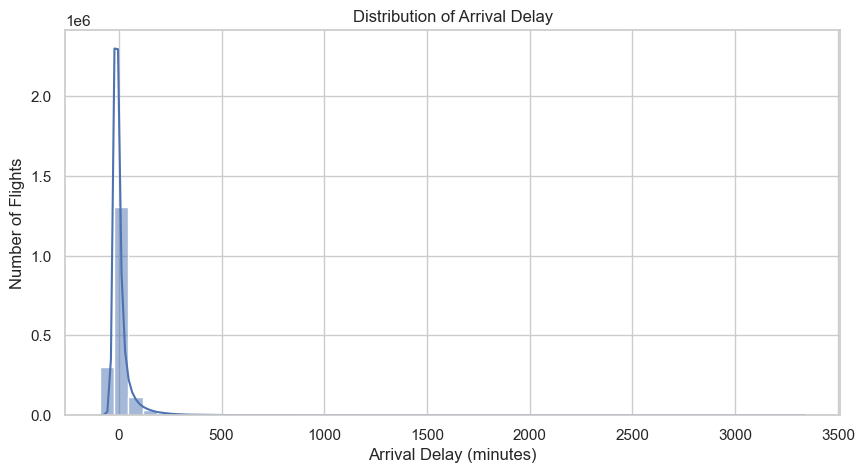

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(
    completed_df["arr_delay"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Arrival Delay")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")
plt.show()

## 12. Boxplot

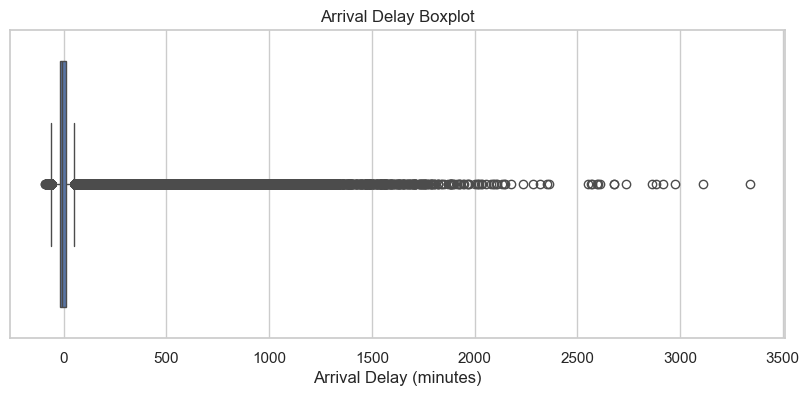

In [18]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=completed_df["arr_delay"])

plt.title("Arrival Delay Boxplot")
plt.xlabel("Arrival Delay (minutes)")
plt.show()

## 13. Skewness

In [19]:
dep_skewness = completed_df["dep_delay"].skew()
arr_skewness = completed_df["arr_delay"].skew()

print("Departure delay skewness:", round(dep_skewness, 2))
print("Arrival delay skewness:", round(arr_skewness, 2))

Departure delay skewness: 10.79
Arrival delay skewness: 9.72


### Simple interpretation

- Around 0 → roughly symmetric
- Positive value → longer right tail
- Negative value → longer left tail

Airline delay data commonly needs careful interpretation because extreme delays can create a long right tail.

## 14. Correlation

In [20]:
correlation = completed_df[[
    "dep_delay",
    "arr_delay",
    "air_time",
    "distance",
    "taxi_out",
    "taxi_in"
]].corr()

correlation

,dep_delay,arr_delay,air_time,distance,taxi_out,taxi_in
dep_delay,1.000000,0.969316,0.005999,0.005164,0.070552,0.023088
arr_delay,0.969316,1.000000,0.000570,-0.015471,0.215296,0.111634
air_time,0.005999,0.000570,1.000000,0.978828,0.002018,0.046851
distance,0.005164,-0.015471,0.978828,1.000000,-0.013570,0.037559
taxi_out,0.070552,0.215296,0.002018,-0.013570,1.000000,0.022657
taxi_in,0.023088,0.111634,0.046851,0.037559,0.022657,1.000000


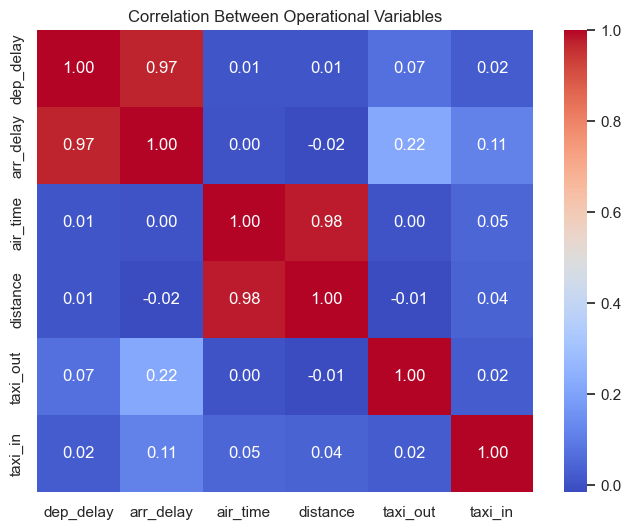

In [21]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Operational Variables")
plt.show()

### Important

Correlation measures the strength and direction of a relationship.

**Correlation does not prove causation.**

## 15. Confidence interval for mean arrival delay

A confidence interval gives a range of plausible values for the population mean.

Here we calculate a **95% confidence interval** for average arrival delay.

In [22]:
arr_delay = completed_df["arr_delay"].dropna()

sample_mean = arr_delay.mean()
sample_std = arr_delay.std()
sample_size = len(arr_delay)

standard_error = sample_std / np.sqrt(sample_size)

confidence_level = 0.95
alpha = 1 - confidence_level

t_critical = stats.t.ppf(1 - alpha / 2, df=sample_size - 1)

margin_of_error = t_critical * standard_error

lower = sample_mean - margin_of_error
upper = sample_mean + margin_of_error

print("Sample mean:", round(sample_mean, 2))
print("95% confidence interval:")
print("Lower:", round(lower, 2))
print("Upper:", round(upper, 2))

Sample mean: 7.25
95% confidence interval:
Lower: 7.16
Upper: 7.34


### Interpretation

The 95% confidence interval gives a reasonable range for the population's average arrival delay based on this sample.

Do not interpret it as saying there is a 95% probability that the fixed population mean is inside this particular interval.

# 16. Hypothesis Testing

## Basic idea

Hypothesis testing helps us decide whether the evidence in the data is strong enough to reject a claim.

### Significance level

We will use:

**α = 0.05**

### General rule

- p-value < 0.05 → Reject H₀
- p-value ≥ 0.05 → Fail to reject H₀

We should not say "prove H₀ is true." A non-significant result only means that the evidence was not strong enough to reject H₀.

# 17. Hypothesis Test 1 — Is average arrival delay different from zero?

### Business question

**Are completed flights, on average, significantly different from an on-time arrival?**

### Hypotheses

**H₀:** Mean arrival delay = 0 minutes

**H₁:** Mean arrival delay ≠ 0 minutes

### Test

One-sample t-test

In [23]:
arr_delay = completed_df["arr_delay"].dropna()

t_stat, p_value = stats.ttest_1samp(arr_delay, 0)

print("t-statistic:", round(t_stat, 4))
print("p-value:", p_value)

t-statistic: 152.3905
p-value: 0.0


In [24]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("There is statistically significant evidence that mean arrival delay differs from 0.")
else:
    print("Fail to reject H0")
    print("There is not enough evidence to say mean arrival delay differs from 0.")

Reject H0
There is statistically significant evidence that mean arrival delay differs from 0.


# 18. Hypothesis Test 2 — Weekend vs weekday departure delays

### Business question

**Is average departure delay different between weekdays and weekends?**

### Hypotheses

**H₀:** Mean departure delay is the same for weekdays and weekends.

**H₁:** Mean departure delay is different for weekdays and weekends.

### Test

Independent two-sample t-test

In [25]:
df["day_name"] = df["fl_date"].dt.day_name()

weekday_df = df[
    (~df["day_name"].isin(["Saturday", "Sunday"])) &
    (df["flight_status"] == "COMPLETED")
]

weekend_df = df[
    (df["day_name"].isin(["Saturday", "Sunday"])) &
    (df["flight_status"] == "COMPLETED")
]

weekday_delay = weekday_df["dep_delay"].dropna()
weekend_delay = weekend_df["dep_delay"].dropna()

print("Weekday flights:", len(weekday_delay))
print("Weekend flights:", len(weekend_delay))

Weekday flights: 1287109
Weekend flights: 493085


In [26]:
t_stat, p_value = stats.ttest_ind(
    weekday_delay,
    weekend_delay,
    equal_var=False
)

print("t-statistic:", round(t_stat, 4))
print("p-value:", p_value)

t-statistic: -24.1762
p-value: 4.369025038742896e-129


In [27]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("There is statistically significant evidence of a difference in mean departure delay.")
else:
    print("Fail to reject H0")
    print("There is not enough evidence of a difference in mean departure delay.")

Reject H0
There is statistically significant evidence of a difference in mean departure delay.


# 19. Compare the group means

In [28]:
print("Average weekday departure delay:",
      round(weekday_delay.mean(), 2))

print("Average weekend departure delay:",
      round(weekend_delay.mean(), 2))

print("Difference:",
      round(weekday_delay.mean() - weekend_delay.mean(), 2))

Average weekday departure delay: 13.12
Average weekend departure delay: 15.62
Difference: -2.49


# 20. Hypothesis Test 3 — Cancellation and airline

### Business question

**Is flight cancellation related to the airline?**

### Hypotheses

**H₀:** Cancellation status and airline are independent.

**H₁:** Cancellation status and airline are associated.

### Test

Chi-square test of independence

In [29]:
cancellation_table = pd.crosstab(
    df["mkt_carrier"],
    df["cancelled"]
)

cancellation_table.head()

cancelled,0.0,1.0
mkt_carrier,,
AA,460957,22945
AS,114331,2158
B6,54310,3010
DL,372504,14328
F9,49152,1405


In [30]:
chi2, p_value, degrees_of_freedom, expected = stats.chi2_contingency(
    cancellation_table
)

print("Chi-square statistic:", round(chi2, 4))
print("Degrees of freedom:", degrees_of_freedom)
print("p-value:", p_value)

Chi-square statistic: 11166.4599
Degrees of freedom: 8
p-value: 0.0


In [31]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("There is statistically significant evidence of an association between airline and cancellation status.")
else:
    print("Fail to reject H0")
    print("There is not enough evidence of an association between airline and cancellation status.")

Reject H0
There is statistically significant evidence of an association between airline and cancellation status.


# 21. Hypothesis Test 4 — Delay and airline

### Business question

**Do average arrival delays differ across airlines?**

### Hypotheses

**H₀:** Mean arrival delay is the same across airlines.

**H₁:** At least one airline has a different mean arrival delay.

### Test

One-way ANOVA

In [32]:
airline_groups = []

for airline in completed_df["mkt_carrier"].dropna().unique():
    values = completed_df[
        completed_df["mkt_carrier"] == airline
    ]["arr_delay"].dropna()

    if len(values) >= 30:
        airline_groups.append(values)

In [33]:
f_stat, p_value = stats.f_oneway(*airline_groups)

print("F-statistic:", round(f_stat, 4))
print("p-value:", p_value)

F-statistic: 788.6111
p-value: 0.0


In [34]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("There is statistically significant evidence that average arrival delay differs across airlines.")
else:
    print("Fail to reject H0")
    print("There is not enough evidence of a difference in average arrival delay across airlines.")

Reject H0
There is statistically significant evidence that average arrival delay differs across airlines.


### Important ANOVA note

If ANOVA is significant, it tells us that **at least one group differs**.

It does not tell us which specific airlines differ.

For this beginner-friendly project, we will stop here rather than adding advanced post-hoc tests.

# 22. Hypothesis Test 5 — Departure delay vs arrival delay

### Business question

**Is there a relationship between departure delay and arrival delay?**

### Hypotheses

**H₀:** There is no linear relationship between departure delay and arrival delay.

**H₁:** There is a linear relationship between departure delay and arrival delay.

### Test

Pearson correlation test

In [35]:
correlation_data = completed_df[
    ["dep_delay", "arr_delay"]
].dropna()

r_value, p_value = stats.pearsonr(
    correlation_data["dep_delay"],
    correlation_data["arr_delay"]
)

print("Correlation:", round(r_value, 4))
print("p-value:", p_value)

Correlation: 0.9693
p-value: 0.0


In [36]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0")
    print("There is statistically significant evidence of a linear relationship.")
else:
    print("Fail to reject H0")
    print("There is not enough evidence of a linear relationship.")

Reject H0
There is statistically significant evidence of a linear relationship.


# 23. Statistical significance vs business significance

A statistically significant result does **not automatically mean the difference is important to the business**.

For example:

- A very small delay difference can become statistically significant with millions of flights.
- But the business may not consider a 1-minute difference operationally important.
- A larger difference may have meaningful effects on customer experience and airline operations.

Always report:

**Statistical result + Actual difference + Business impact**

# 24. Statistical summary table

In [37]:
statistics_summary = pd.DataFrame({
    "Metric": [
        "Mean Departure Delay",
        "Median Departure Delay",
        "Std Departure Delay",
        "Mean Arrival Delay",
        "Median Arrival Delay",
        "Std Arrival Delay",
        "Departure Delay Skewness",
        "Arrival Delay Skewness"
    ],
    "Value": [
        round(completed_df["dep_delay"].mean(), 2),
        round(completed_df["dep_delay"].median(), 2),
        round(completed_df["dep_delay"].std(), 2),
        round(completed_df["arr_delay"].mean(), 2),
        round(completed_df["arr_delay"].median(), 2),
        round(completed_df["arr_delay"].std(), 2),
        round(completed_df["dep_delay"].skew(), 2),
        round(completed_df["arr_delay"].skew(), 2)
    ]
})

statistics_summary

,Metric,Value
0,Mean Departure Delay,13.81
1,Median Departure Delay,-2.00
2,Std Departure Delay,60.74
3,Mean Arrival Delay,7.25
4,Median Arrival Delay,-7.00
5,Std Arrival Delay,63.47
6,Departure Delay Skewness,10.79
7,Arrival Delay Skewness,9.72


# 25. Hypothesis testing summary

In [38]:
print("Test 1: Mean arrival delay vs 0")
print("p-value:", p_value)

Test 1: Mean arrival delay vs 0
p-value: 0.0


For the final project, record each test using this format:

| Test | H₀ | Test | p-value | Decision | Business meaning |
|---|---|---|---:|---|---|
| Arrival delay vs 0 | Mean = 0 | One-sample t-test | Run above | Based on p-value | Is average arrival performance different from on-time? |
| Weekday vs weekend | Means equal | Welch t-test | Run above | Based on p-value | Are delay patterns different by day type? |
| Cancellation vs airline | Independent | Chi-square | Run above | Based on p-value | Is cancellation associated with airline? |
| Arrival delay by airline | Means equal | ANOVA | Run above | Based on p-value | Do airlines differ in average arrival delay? |
| Departure vs arrival delay | No linear relationship | Pearson correlation | Run above | Based on p-value | Does departure delay carry through to arrival? |

# 27. Interview explanation

If an interviewer asks **"Why did you use hypothesis testing?"**, a simple answer is:

> "EDA showed differences and patterns in the airline data. I used hypothesis testing to check whether some of those observed differences were statistically significant rather than relying only on descriptive statistics."

If asked **"Why did you use a t-test?"**:

> "I used a t-test when comparing the mean of a continuous metric between two groups."

If asked **"Why chi-square?"**:

> "I used chi-square because cancellation and airline are categorical variables, and I wanted to test whether they are associated."

If asked **"Why ANOVA?"**:

> "I used ANOVA because I wanted to compare the mean arrival delay across more than two airline groups."

# ✅ Statistics analysis complete

### Final workflow

**Data Cleaning → EDA → Statistics → Hypothesis Testing → Business Insights → Power BI**

Keep the statistics focused on questions that matter to airline operations.

**Do not add advanced statistical methods just to make the project look difficult.**